# Atividade 6 — Desocupação feminina e afazeres domésticos

As duas Tabelas 5 são unificadas por unidade da Federação e cruzadas com a Tabela 1.1.1 da Aula 2. O gráfico principal compara a participação das mulheres entre as pessoas desocupadas em 2012 T1 e 2026 T1.

Se necessário, execute uma vez no terminal: `python -m pip install pandas matplotlib seaborn xlrd`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
palette = {"2012 T1": "#4C78A8", "2026 T1": "#F58518"}

raizes = [Path.cwd(), *Path.cwd().parents]
projeto = next(
    (
        raiz
        for raiz in raizes
        if (raiz / "atividade2").is_dir() and (raiz / "atividade6").is_dir()
    ),
    Path.cwd(),
)
pasta_atividade6 = projeto / "atividade6"
pasta_aula2 = projeto / "atividade2"

## 1. Abrir e tratar as duas Tabelas 5

Os arquivos usam ponto e vírgula como separador e vírgula decimal. As colunas são renomeadas para facilitar a comparação entre os dois anos.

In [2]:
def ler_tabela5(caminho, ano):
    tabela = pd.read_csv(
        caminho,
        sep=";",
        decimal=",",
        encoding="utf-8-sig",
    )
    tabela = tabela.rename(
        columns={
            f"Desocupados - homens ({ano} T1)": f"homens_{ano}",
            f"Desocupados - mulheres ({ano} T1)": f"mulheres_{ano}",
        }
    )
    tabela[f"homens_{ano}"] = pd.to_numeric(
        tabela[f"homens_{ano}"], errors="coerce"
    )
    tabela[f"mulheres_{ano}"] = pd.to_numeric(
        tabela[f"mulheres_{ano}"], errors="coerce"
    )
    return tabela

t2012 = ler_tabela5(
    pasta_atividade6 / "Tabela5-sem_emprego_2012.csv", "2012"
)
t2026 = ler_tabela5(
    pasta_atividade6 / "Tabela5-sem_emprego_2026.csv", "2026"
)

print(f"Tabela 2012: {t2012.shape[0]} estados")
print(f"Tabela 2026: {t2026.shape[0]} estados")
t2012

Tabela 2012: 27 estados
Tabela 2026: 27 estados


,Sigla,Código,Estado,homens_2012,mulheres_2012
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2
5,CE,23,Ceará,51.1,48.9
6,DF,53,Distrito Federal,41.0,59.0
7,ES,32,Espírito Santo,46.4,53.6
8,GO,52,Goiás,41.0,59.0
9,MA,21,Maranhão,47.2,52.8


## 2. Tratar a Tabela 1.1.1 da Aula 2

A planilha tem títulos, cabeçalhos em várias linhas e notas no rodapé. O corte das linhas 8 a 40 segue o tratamento feito na Aula 2. Depois, são mantidas somente as unidades da Federação presentes nas Tabelas 5.

In [3]:
bruto_aula2 = pd.read_excel(
    pasta_aula2 / "Tabela 1.1.1.xls",
    engine="xlrd",
    header=None,
)

indicador_1 = bruto_aula2.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)

for coluna in indicador_1.columns[1:]:
    indicador_1[coluna] = pd.to_numeric(
        indicador_1[coluna], errors="coerce"
    )

t2022 = indicador_1.loc[
    indicador_1["uf_regiao"].isin(t2026["Estado"]),
    [
        "uf_regiao",
        "total",
        "total_branca",
        "total_preta_parda",
        "homem_branca",
        "homem_preta_parda",
        "mulher_branca",
        "mulher_preta_parda",
    ],
].copy()
t2022 = t2022.rename(columns={"uf_regiao": "Estado"})
t2022["horas_homens"] = (
    t2022["homem_branca"] + t2022["homem_preta_parda"]
) / 2
t2022["horas_mulheres"] = (
    t2022["mulher_branca"] + t2022["mulher_preta_parda"]
) / 2

print(f"Estados mantidos na Tabela 1.1.1: {len(t2022)}")
t2022

Estados mantidos na Tabela 1.1.1: 27


,Estado,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda,horas_homens,horas_mulheres
2,Rondônia,17.014162,16.727733,17.101523,12.111127,12.544080,20.412887,21.061410,12.327604,20.737149
3,Acre,13.606903,13.806929,13.541399,10.796120,9.686983,16.130352,16.710754,10.241551,16.420553
4,Amazonas,16.807290,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986,12.527813,19.740977
5,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244,10.645702,16.348061
6,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.835110,21.591144,11.275506,20.713127
7,Amapá,13.586656,14.389180,13.415091,11.116821,10.749444,16.648579,15.908487,10.933133,16.278533
8,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399,11.208240,19.646556
10,Maranhão,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589,11.551266,20.310323
11,Piauí,17.960366,16.948094,18.231789,12.258324,11.204814,20.494063,23.695440,11.731569,22.094752
12,Ceará,19.499293,18.527120,19.882469,12.186936,12.821323,23.019718,24.952274,12.504129,23.985996


## 3. Juntar as três tabelas com `merge`

Primeiro, as Tabelas 5 são combinadas por sigla, código e estado. Em seguida, os dados de 2022 da Tabela 1.1.1 são cruzados pelo nome do estado. A variável `variacao_pp` mostra a mudança da participação feminina em pontos percentuais.

In [4]:
comp = t2012.merge(
    t2026,
    on=["Sigla", "Código", "Estado"],
    how="inner",
)
comp = comp.merge(
    t2022,
    on="Estado",
    how="inner",
)
comp["variacao_pp"] = comp["mulheres_2026"] - comp["mulheres_2012"]
comp = comp.sort_values("mulheres_2026", ascending=False).reset_index(drop=True)

print(f"Linhas após as três junções: {len(comp)}")
comp[["Estado", "mulheres_2012", "mulheres_2026", "variacao_pp", "total", "horas_mulheres"]]

Linhas após as três junções: 27


,Estado,mulheres_2012,mulheres_2026,variacao_pp,total,horas_mulheres
0,Rondônia,56.6,67.0,10.4,17.014162,20.737149
1,Sergipe,53.5,59.7,6.2,18.826541,23.689292
2,Mato Grosso,55.9,57.2,1.3,14.239989,18.239374
3,Roraima,58.2,56.6,-1.6,13.639257,16.348061
4,Santa Catarina,57.3,55.4,-1.9,16.039355,19.530669
5,Bahia,56.2,55.3,-0.9,17.849776,22.894924
6,Mato Grosso do Sul,52.8,54.7,1.9,15.309783,19.067981
7,Rio de Janeiro,55.8,54.6,-1.2,16.716263,20.080735
8,São Paulo,54.6,53.8,-0.8,17.071295,21.269403
9,Tocantins,44.7,53.8,9.1,15.815781,19.646556


## 4. Gráfico solicitado: participação feminina na desocupação

A função `melt` transforma as duas colunas de participação em duas linhas por estado. A linha vertical tracejada representa 50%, referência de paridade entre homens e mulheres.

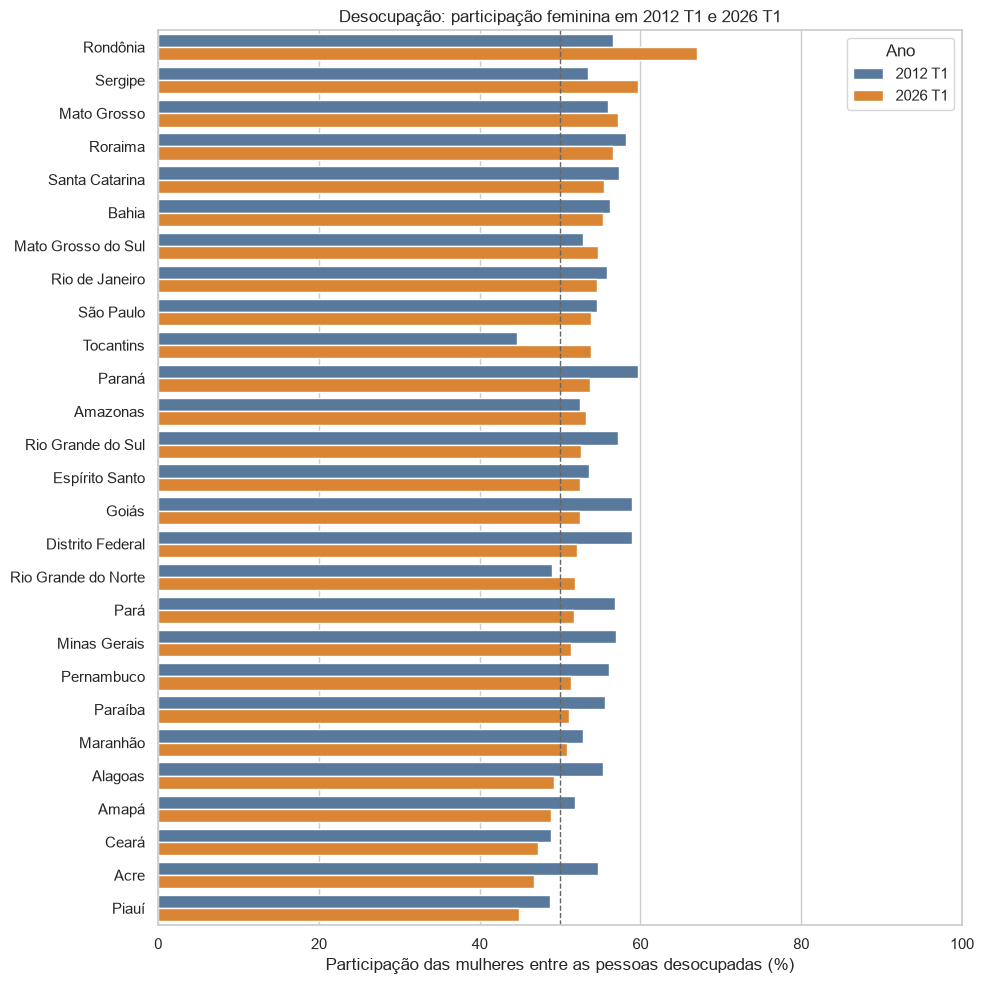

In [5]:
ordem = comp.sort_values("mulheres_2026", ascending=False)["Estado"]
longo = comp.melt(
    id_vars=["Sigla", "Código", "Estado"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map(
    {"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"}
)

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    hue_order=["2012 T1", "2026 T1"],
    order=ordem,
    palette=palette,
    ax=ax,
)
ax.axvline(50, color="#666666", linestyle="--", linewidth=1)
ax.set_xlim(0, 100)
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Ano")
fig.tight_layout()
plt.show()

## 5. Leitura cruzada com a Tabela 1.1.1

A visualização abaixo usa o mesmo `comp` para relacionar, de forma exploratória, as horas médias semanais de afazeres domésticos em 2022 com a participação feminina na desocupação em 2026. `horas_mulheres` é a média simples das duas categorias de cor disponíveis na tabela.

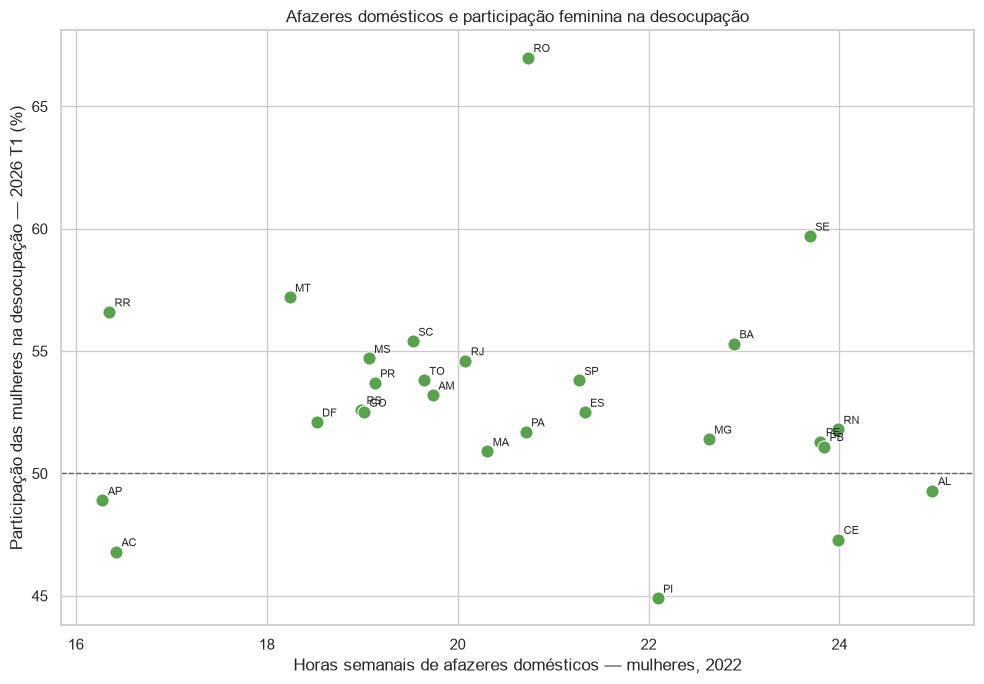

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=comp,
    x="horas_mulheres",
    y="mulheres_2026",
    color="#59A14F",
    s=90,
    ax=ax,
)
for _, linha in comp.iterrows():
    ax.annotate(
        linha["Sigla"],
        (linha["horas_mulheres"], linha["mulheres_2026"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )
ax.axhline(50, color="#666666", linestyle="--", linewidth=1)
ax.set_xlabel("Horas semanais de afazeres domésticos — mulheres, 2022")
ax.set_ylabel("Participação das mulheres na desocupação — 2026 T1 (%)")
ax.set_title("Afazeres domésticos e participação feminina na desocupação")
fig.tight_layout()
plt.show()